<a href="https://colab.research.google.com/github/Saransh-Basu-01/50-Ml-Projects-to-understand-LLMs/blob/main/Project_8_Distribution_of_Cosine_Similarity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import matplotlib.gridspec as gridspec

# Background

In [3]:
from transformers import BertTokenizer, BertModel

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
embeddings = model.embeddings.word_embeddings.weight.detach()
print(f'Embedding matrix shape: {embeddings.shape}')

Embedding matrix shape: torch.Size([30522, 768])


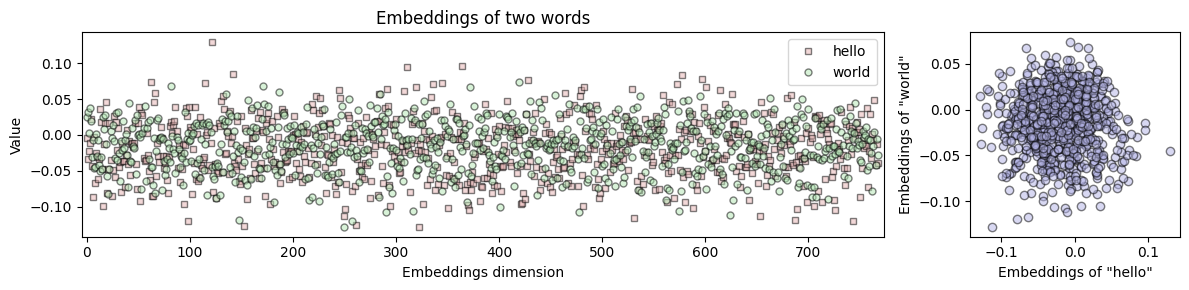

In [6]:

word1 = 'hello'
word2 = 'world'

token1 = tokenizer.encode(word1,add_special_tokens=False)
token2 = tokenizer.encode(word2,add_special_tokens=False)

emb1 = embeddings[token1,:].squeeze()
emb2 = embeddings[token2,:].squeeze()

fig = plt.figure(figsize=(12,3))
gs = gridspec.GridSpec(1,4,figure=fig)
ax1 = fig.add_subplot(gs[:3])
ax2 = fig.add_subplot(gs[-1])

ax1.plot(emb1,'ks',markerfacecolor=[.9,.7,.7,.5],markersize=5,label=word1)
ax1.plot(emb2,'ko',markerfacecolor=[.7,.9,.7,.5],markersize=5,label=word2)

ax1.set(xlabel='Embeddings dimension',ylabel='Value',xlim=[-5,len(emb1)+5],title='Embeddings of two words')
ax1.legend()

ax2.plot(emb1,emb2,'ko',markerfacecolor=[.7,.7,.9,.5])
ax2.set(xlabel=f'Embeddings of "{word1}"',ylabel=f'Embeddings of "{word2}"')

plt.tight_layout()
plt.show()

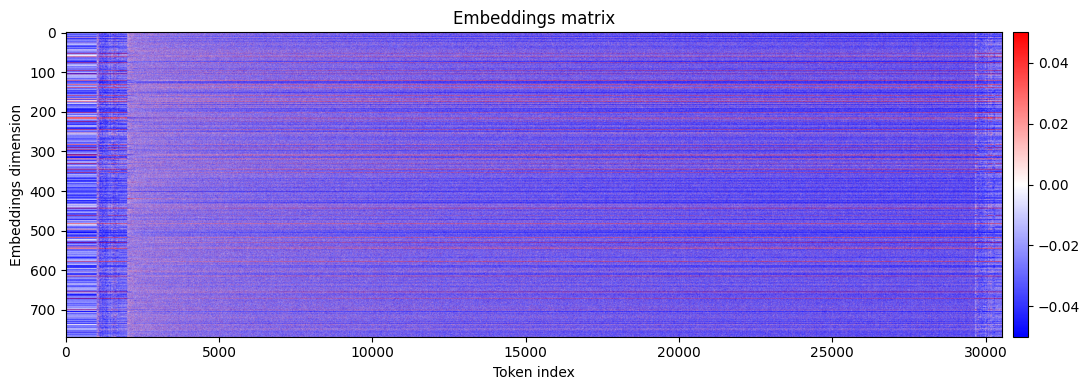

In [7]:
plt.figure(figsize=(12,4))
plt.imshow(embeddings.T,vmin=-.05,vmax=.05,aspect='auto',cmap='bwr')

plt.gca().set(xlabel='Token index',ylabel='Embeddings dimension',
              title='Embeddings matrix')

plt.colorbar(pad=.01)
plt.tight_layout()
plt.show()

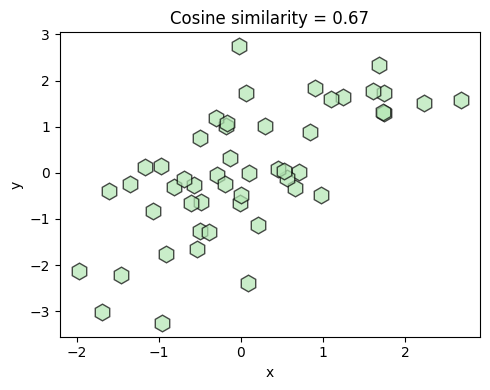

In [8]:
x = np.random.randn(50)
y = x + np.random.randn(50)

# manual cosine similarity
num = np.sum(x*y)
norm_x = np.sum(x**2)
norm_y = np.sum(y**2)
den = np.sqrt( norm_x*norm_y )
cs = num/den

plt.figure(figsize=(5,4))
plt.plot(x,y,'kh',markerfacecolor=[.7,.9,.7,.7],markersize=12)
plt.gca().set(xlabel='x',ylabel='y',
              title=f'Cosine similarity = {cs:.2f}')

plt.tight_layout()
plt.show()

In [13]:
n = 100 # observations
m = 15  # features

X = np.random.randn(n,m) + np.linspace(-2,2,m)

# normalize (note the vector_norm not matrix_norm!)
# also be careful of which axis to normalize depending on matrix dimension
X_norm = X / np.linalg.norm(X,axis=0,keepdims=True)

# cosine similarity matrix (note the transpose on the first matrix)
csM = X_norm.T @ X_norm

# correlation matrix
R = np.corrcoef(X.T)

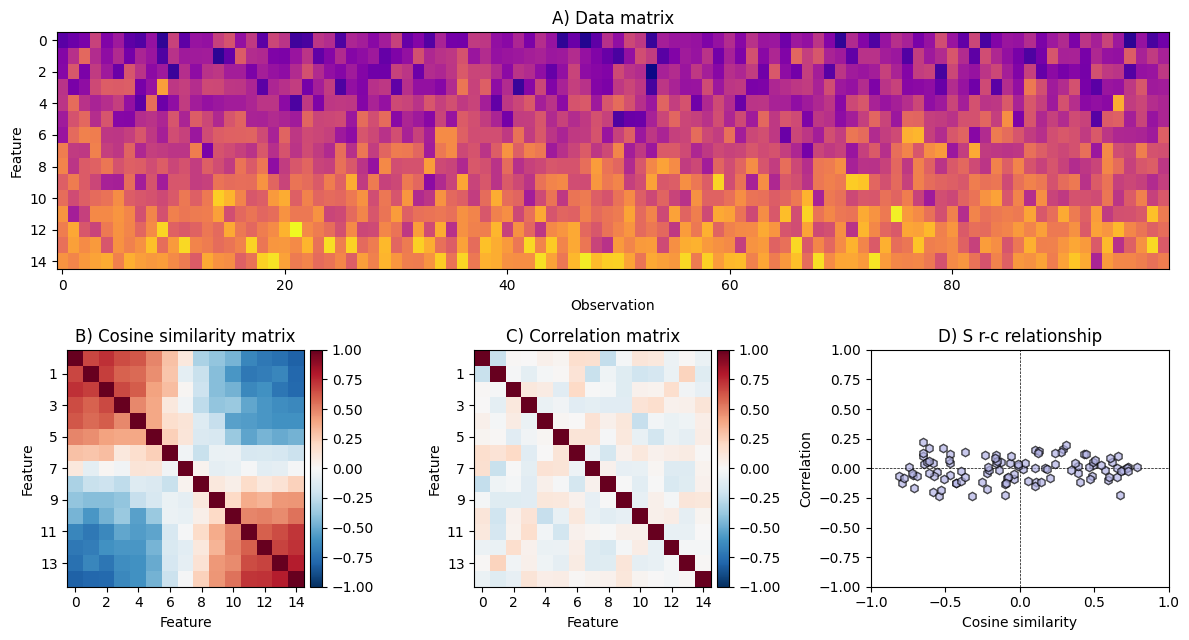

In [14]:

fig = plt.figure(figsize=(12,6.5))
gs = gridspec.GridSpec(2,3,figure=fig)
ax1 = fig.add_subplot(gs[0,:])
ax2 = fig.add_subplot(gs[1,0])
ax3 = fig.add_subplot(gs[1,1])
ax4 = fig.add_subplot(gs[1,2])


ax1.imshow(X.T,aspect='auto',cmap='plasma')
ax1.set(xlabel='Observation',ylabel='Feature',title='A) Data matrix')

# and the cosine similarity matrix
h = ax2.imshow(csM,vmin=-1,vmax=1,cmap='RdBu_r')
fig.colorbar(h,ax=ax2,pad=.02)
ax2.set(xlabel='Feature',ylabel='Feature',xticks=range(0,m,2),yticks=range(1,m,2),
           title='B) Cosine similarity matrix')

# and the cosine similarity matrix
h = ax3.imshow(R,vmin=-1,vmax=1,cmap='RdBu_r')
fig.colorbar(h,ax=ax3,pad=.02)
ax3.set(xlabel='Feature',ylabel='Feature',xticks=range(0,m,2),yticks=range(1,m,2),
           title='C) Correlation matrix')


unique_cs = csM[np.triu_indices(csM.shape[0],k=1)]
unique_rs = R[np.triu_indices(R.shape[0],k=1)]

ax4.axhline(0,linestyle='--',color='k',linewidth=.5)
ax4.axvline(0,linestyle='--',color='k',linewidth=.5)
ax4.plot(unique_cs,unique_rs,'kh',markerfacecolor=[.7,.7,.9,.7])
ax4.set(xlabel='Cosine similarity',ylabel='Correlation',xlim=[-1,1],ylim=[-1,1],
        title='D) S r-c relationship')

plt.tight_layout()
plt.show()

# Part_1:Similarity of embedding pairs

## Task_1:
- Use the NumPy function choice to select two tokens at random
between index 3000 and 6000 from the BERT tokenizer, and print
their corresponding strings.
Extract the two embeddings vectors from the BERT model,
and create a scatter plot between them as in Figure 3.7.

In [39]:
tokenpair=np.random.choice(np.arange(3000,6001),2)

In [33]:
# or pick two words
word1 = 'sunshine'
word2 = 'pineapple'

# tokenize
# tokenpair = tokenizer.encode([word1,word2],add_special_tokens=False)

In [40]:
tokenpair

array([3691, 5640])

In [41]:
for t in tokenpair:
  print(f'{t:5} is "{tokenizer.decode(t)}"')

 3691 is "authority"
 5640 is "arabic"


In [42]:
v1=embeddings[tokenpair[0]]
v2=embeddings[tokenpair[1]]
v1_token = tokenizer.decode(tokenpair[0])
v2_token = tokenizer.decode(tokenpair[1])

print(f'Token pair: "{v1_token}" and "{v2_token}"')
print(f'Embedding shape: {v1.shape}')

Token pair: "authority" and "arabic"
Embedding shape: torch.Size([768])


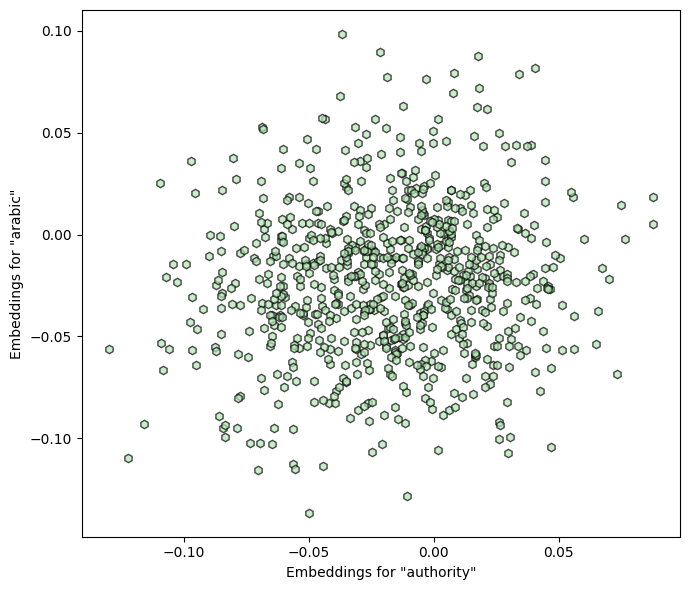

In [43]:
plt.figure(figsize=(7,6))

plt.plot(v1,v2,'kh',markerfacecolor=[.7,.9,.7,.7])
plt.gca().set(xlabel=f'Embeddings for "{v1_token}"',ylabel=f'Embeddings for "{v2_token}"')

plt.tight_layout()
plt.show()


## Task_2:
- Calculate cosine similarity between the two embeddings vectors. Run
the analysis twice: Once by directly implementing the formulas you
learned at the start of this chapter (if you copy code from earlier
in the code file, be mindful that the embeddings vectors are PyTorch
tensors, not NumPy arrays), and again using the cosine_similarity
function in PyTorch. Print both results to confirm they are identical.

In [24]:
import torch

In [44]:
num = torch.sum(v1*v2)
norm_v1 = torch.sqrt( torch.sum(v1**2) )
norm_v2 = torch.linalg.norm(v2)
den = norm_v1*norm_v2

print(f'Shape of vectors: {v1.shape}')
manual_cs = num/den

Shape of vectors: torch.Size([768])


In [28]:
manual_cs

tensor(0.3345)

In [45]:
v1_t = v1.unsqueeze(dim=0)
v2_t = v2.view(1,-1) # both view() and unsqueeze() work in this case

print(f'Shape of torch vectors: {v1_t.shape}')
torch_cs = torch.cosine_similarity(v1_t,v2_t)

Shape of torch vectors: torch.Size([1, 768])


In [46]:
print(f'Manual cosine similarity:  {manual_cs:.5f}')
print(f'Pytorch cosine similarity: {torch_cs.item():.5f}')

Manual cosine similarity:  0.30938
Pytorch cosine similarity: 0.30938


# Part_2:All to All cosine similarity

## Task_1:
- Create the cosine similarity matrix as EE⊤ where E is the tokens ×
embeddings dimension matrix

In [48]:
# normalize (note the vector_norm not matrix_norm!)
# important: compare dim=1 here to dim=0 earlier (also note that numpy calls it "axis" instead of "dim")
E_norm = embeddings / torch.linalg.norm(embeddings,dim=1,keepdim=True)

# cosine similarity matrix (note which matrix is transposed)
csM = E_norm @ E_norm.T

# check size
print(f'Cosine similarity matrix shape: {csM.shape} ({np.prod(csM.shape):,} total elements!)')

Cosine similarity matrix shape: torch.Size([30522, 30522]) (931,592,484 total elements!)


## Task_2:
- Monitor your RAM usage before and after each of the following
steps. If you’re using Google Colab, you can click on the Runtime
menu option, then click on View resources. That will open a tab
on the right that shows RAM usage. You can also click on the
RAM/Disk button on the upper-right of the screen.
Then implement the following steps.
• Reduce the precision of the cosine similarity matrix from full
floating point precision to 16-bit (float16), by recasting the
cosine similarity matrix using the .to() method on the PyTorch
tensor.
• Downsample the reduced precision matrix by creating a subma
trix formed from every 3rd row and column. That submatrix is
10174×10174, giving 103,510,276 elements. Still a lot to count
by hand, but much more manageable for a commercial CPU.
• Delete the normalized embeddings matrix after calculating the
cosine similarity matrix (hint: use the function del).
Now you can write code to create Figure 3.8

In [49]:

# check resources (System RAM) before and after running this code block

# reduce precision to save on RAM for subsequent analyses
csM = csM.to(torch.float16)

# and delete unused large variable
del E_norm

In [50]:
skip = 3
csMsub = csM[::skip,::skip]

# check size
print(f'Full matrix shape: {csM.shape} ({np.prod(csM.shape):>11,} total elements!)')
print(f'Submatrix shape  : {csMsub.shape} ({np.prod(csMsub.shape):>11,} total elements!)')


Full matrix shape: torch.Size([30522, 30522]) (931,592,484 total elements!)
Submatrix shape  : torch.Size([10174, 10174]) (103,510,276 total elements!)


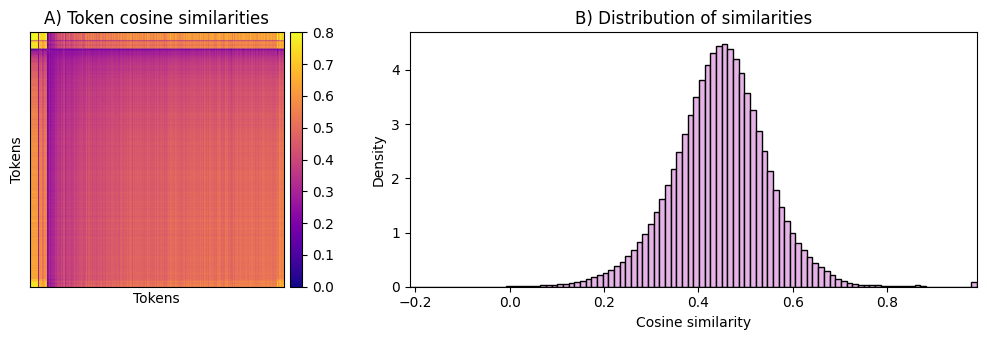

In [51]:
cs_nonredun = csMsub[np.triu_indices(csMsub.shape[0],k=1)]

fig,axs = plt.subplots(1,2,figsize=(12,3.5))

h = axs[0].imshow(csMsub,vmin=0,vmax=.8,cmap='plasma')
axs[0].set(title='A) Token cosine similarities',xticks=[],yticks=[],
           xlabel='Tokens',ylabel='Tokens')
plt.colorbar(h,ax=axs[0],pad=.01)

axs[1].hist(cs_nonredun,bins=100,density=True,color=[.9,.7,.9],edgecolor='k')
axs[1].set(xlabel='Cosine similarity',ylabel='Density',
           xlim=[cs_nonredun.min(),cs_nonredun.max()],
           title='B) Distribution of similarities')

plt.tight_layout()
plt.show()

# Part_3: Berts Unused Tokens

In [54]:
for i in range(20):
  print(f'Token {i:2} is "{tokenizer.decode(i)}"')

Token  0 is "[PAD]"
Token  1 is "[unused0]"
Token  2 is "[unused1]"
Token  3 is "[unused2]"
Token  4 is "[unused3]"
Token  5 is "[unused4]"
Token  6 is "[unused5]"
Token  7 is "[unused6]"
Token  8 is "[unused7]"
Token  9 is "[unused8]"
Token 10 is "[unused9]"
Token 11 is "[unused10]"
Token 12 is "[unused11]"
Token 13 is "[unused12]"
Token 14 is "[unused13]"
Token 15 is "[unused14]"
Token 16 is "[unused15]"
Token 17 is "[unused16]"
Token 18 is "[unused17]"
Token 19 is "[unused18]"


## Task_1:
- Create a Boolean vector that equals True for any unused token and
False for all other tokens. Then create Figure 3.9 to show which
tokens, and how many, are unused. Be careful with the string match
ing: There might be other tokens that contain the word “unused” but
are not actually the [unused] tokens you want to identify

In [56]:
tokenizer.vocab_size

30522

In [58]:
unused_tokens=torch.zeros(tokenizer.vocab_size,dtype=bool)
for i in range(tokenizer.vocab_size):
  if '[unused' in tokenizer.decode(i):
    unused_tokens[i]=True
titleinfo = f'{unused_tokens.sum()}/{tokenizer.vocab_size} ({100*unused_tokens.sum()/tokenizer.vocab_size:.2f}%) "unused" tokens'
titleinfo

'994/30522 (3.26%) "unused" tokens'

In [62]:
# sum() counts how many True values there are:
num_unused = sum(unused_tokens)
print(f"Number of unused tokens: {num_unused}")

Number of unused tokens: 994


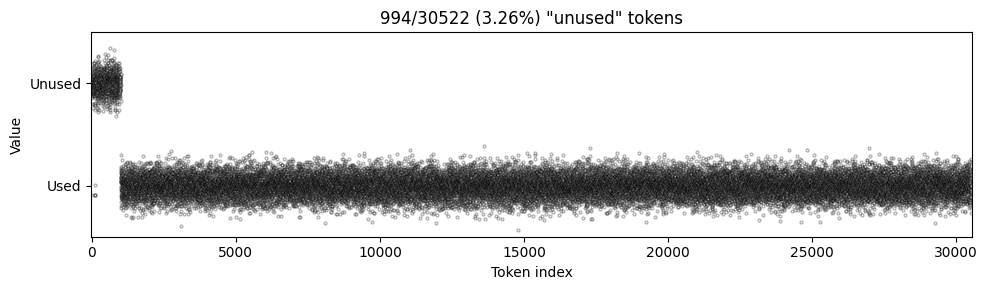

In [69]:
plt.figure(figsize=(10,3))
plt.plot(range(tokenizer.vocab_size),torch.randn(tokenizer.vocab_size)/10+unused_tokens,
         'ko',markersize=2,markerfacecolor='w',alpha=.3)
plt.gca().set(xlabel='Token index',ylabel='Value',yticks=[0,1],yticklabels=['Used','Unused'],ylim=[-.5,1.5],
              xlim=[-15,len(unused_tokens)+15],title=titleinfo)

plt.tight_layout()
plt.show()